In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install -U insightface opencv-python-headless numpy matplotlib
!pip install --force-reinstall onnxruntime-gpu

import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis

print("InsightFace version:", insightface.__version__)


  Using cached onnxruntime_gpu-1.24.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 5.7 MB/s eta 0:00:00
Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 47.6 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
     

InsightFace version: 0.7.3


In [29]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
from google.colab.patches import cv2_imshow

app = FaceAnalysis(name='buffalo_l', root='~/.insightface', allowed_modules=['detection', 'recognition'])
app.prepare(ctx_id=0, det_size=(640, 640))

def get_embedding(image):
    faces = app.get(image)
    if len(faces) == 0:
        return None
    return faces[0].embedding

print("Model loaded successfully!")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

In [9]:
import os

celebrity_names = ['robert_downey_jr', 'chris_hemsworth', 'chris_evans']
database = {}

for name in celebrity_names:
    embeddings = []
    print(f"Registering {name}...")

    for i in range(1, 8):
        img_path = f"/content/drive/MyDrive/face-detec/{name}_{i}.jpg"

        if not os.path.exists(img_path):
            print(f"File {img_path} not found, skipping.")
            continue

        img = cv2.imread(img_path)
        faces = app.get(img)

        if len(faces) > 0:
            embeddings.append(faces[0].embedding)
        else:
            print(f"No face detected in {img_path}")

    if embeddings:
        database[name] = np.mean(embeddings, axis=0)
        print(f"Success: Registered {name} with {len(embeddings)} images.")
    else:
        print(f"Failure: Could not register {name}.")

print("\nDatabase Build Complete!")

Registering robert_downey_jr...
Success: Registered robert_downey_jr with 7 images.
Registering chris_hemsworth...
Success: Registered chris_hemsworth with 7 images.
Registering chris_evans...
Success: Registered chris_evans with 7 images.

Database Build Complete!


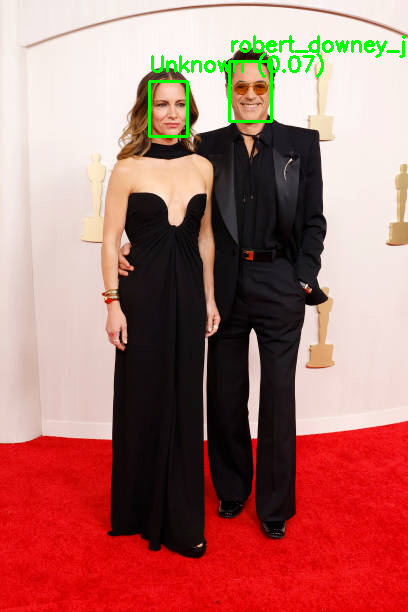

In [28]:
def test_recognition(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found!")
        return

    faces = app.get(img)

    for face in faces:
        emb = face.embedding
        name = "Unknown"
        best_sim = 0

        for db_name, db_emb in database.items():
            sim = np.dot(emb, db_emb) / (np.linalg.norm(emb) * np.linalg.norm(db_emb))
            if sim > best_sim:
                best_sim = sim
                if sim > threshold:
                    name = db_name

        bbox = face.bbox.astype(int)
        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, f"{name} ({best_sim:.2f})", (bbox[0], bbox[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2_imshow(img)

test_recognition('/content/gettyimages-2074301463-612x612.jpg')

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import os

input_video = '/content/drive/MyDrive/face-detec/grok-video-ea683fcd-afa7-47c0-879f-e22e55c6b62b.mp4'
output_video = '/content/drive/MyDrive/face-detec/processed_face_recognition.mp4'

cap = cv2.VideoCapture(input_video)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

print(f"Processing video: {input_video}...")
print("This may take a few minutes depending on video length.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    faces = app.get(frame)

    for face in faces:
        emb = face.embedding
        name = "Unknown"
        max_similarity =

        for db_name, db_vec in database.items():
            sim = np.dot(emb, db_vec) / (np.linalg.norm(emb) * np.linalg.norm(db_vec))
            if sim > max_similarity:
                max_similarity = sim
                if sim > 0.45:
                    name = db_name

        box = face.bbox.astype(int)
        color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
        cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), color, 3)

        label = f"{name} ({max_similarity:.2f})"
        cv2.rectangle(frame, (box[0], box[1] - 30), (box[0] + 200, box[1]), color, -1)
        cv2.putText(frame, label, (box[0] + 5, box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    out.write(frame)

cap.release()
out.release()
print(f"Finished! Video saved at: {output_video}")

Processing video: /content/drive/MyDrive/face-detec/grok-video-ea683fcd-afa7-47c0-879f-e22e55c6b62b.mp4...
This may take a few minutes depending on video length.
Finished! Video saved at: /content/drive/MyDrive/face-detec/processed_face_recognition.mp4
